<a href="https://colab.research.google.com/github/dtoralg/TheValley_MDS/blob/main/%5B07%5D%20-%20Ingenieria_de_Variables_I/%5B01%5D%20-%20Notebooks/E1_Tus_Primeras_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E1 · Tus primeras features — Ingenieria de Variables I

## Introduccion


En **Ingenieria de Variables** preparamos y creamos variables (*features*) para que el
modelo aprenda mejor, usando lo que sabemos del problema. Antes de tocar ningun
algoritmo, conviene mirar la **señal**: una buena variable suele mejorar mas que cambiar de modelo.

En este primer ejercicio trabajamos el **bloque numerico**. Sobre el dataset de fraude con tarjeta vamos a:

1. Identificar el **tipo** de cada variable (y detectar la trampa de las *pseudo-numericas*).
2. Mirar `df.describe()` **antes** de transformar.
3. **Escalar** (StandardScaler, MinMaxScaler, RobustScaler).
4. **Manejar outliers** de una distribucion sesgada con `log`, *winsorizing* y *Yeo-Johnson*.
5. Crear nuestras primeras features: `log_monto`, `monto_ratio` y **sacar el mes** (y mas) de la fecha.
6. Hacer **binning** y comparar `df.describe()` **despues**.

## Objetivos del ejercicio

- Distinguir variables **numericas** de **categoricas** y reconocer **pseudo-numericas**.
- Entender **cuando y por que escalar**, y las diferencias entre los 3 escaladores clasicos.
- Tratar **outliers** y distribuciones sesgadas con transformaciones (`log1p`, winsorizing, Yeo-Johnson).
- Construir features utiles: ratios, descomposicion de fechas y **encoding ciclico** de la hora.
- Aplicar **binning** y comparar el dataset antes y despues.

## Descripcion del dataset (fraude con tarjeta)

Trabajamos con un dataset **sintetico y reproducible** de transacciones con tarjeta.
Lo generamos dentro del propio notebook para que sea autocontenido en Colab.
Cada fila es una transaccion con estas variables:

| Variable | Tipo | Descripcion |
|---|---|---|
| `id_cliente` | id | Identificador del cliente |
| `edad` | numerica | Edad del cliente (con algunos huecos) |
| `monto` | numerica | Importe de la transaccion en euros (distribucion sesgada) |
| `pais` | categorica | Pais de la operacion: ES, DE, UK, FR, IT |
| `tipo_tarjeta` | categorica | debito / credito / prepago |
| `comercio` | categorica (ALTA cardinalidad) | Comercio donde se opera (COM_0000 ... COM_0299, con frecuencias muy desiguales) |
| `canal` | categorica | online / presencial (con algunos huecos) |
| `codigo_postal` | pseudo-numerica | Parece numero, pero NO tiene magnitud |
| `fecha` | fecha/hora | Momento de la transaccion |
| `es_fraude` | objetivo (0/1) | 1 si la transaccion fue fraudulenta |

> La probabilidad real de fraude se ha construido en funcion del monto, la hora,
> el canal, el pais y el comercio. Por eso, **las variables que creemos tendran
> senal de verdad** y veremos su efecto en las metricas.

### 1. Importar librerias necesarias

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

sns.set(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

### 2. Generar el dataset de fraude

In [ ]:
import numpy as np
import pandas as pd

def generar_datos_fraude(n=8000, semilla=42):
    # Dataset sintetico y REPRODUCIBLE de transacciones con tarjeta.
    # La probabilidad de fraude depende de variables reales (monto, hora,
    # canal, pais y comercio): asi la ingenieria de variables tiene senal de verdad.
    rng = np.random.default_rng(semilla)

    # --- Perfil de clientes ---
    n_clientes = 600
    gasto_medio_cliente = rng.lognormal(mean=3.2, sigma=0.5, size=n_clientes)
    edad_por_cliente = rng.integers(18, 80, size=n_clientes)
    id_cliente = rng.integers(0, n_clientes, size=n)

    # --- Comercios (ALTA cardinalidad, con frecuencias MUY desiguales) ---
    n_comercios = 300
    comercios = np.array([f"COM_{i:04d}" for i in range(n_comercios)])
    riesgo_comercio = rng.beta(1.2, 8.0, size=n_comercios)   # casi todos bajos, unos pocos altos
    peso_comercio = 1.0 / np.arange(1, n_comercios + 1)      # ley de potencias: muchos comercios raros
    peso_comercio = peso_comercio / peso_comercio.sum()
    idx_comercio = rng.choice(n_comercios, size=n, p=peso_comercio)

    # --- Categoricas de BAJA cardinalidad ---
    pais = rng.choice(["ES", "DE", "UK", "FR", "IT"], size=n, p=[0.60, 0.12, 0.10, 0.10, 0.08])
    tipo_tarjeta = rng.choice(["debito", "credito", "prepago"], size=n, p=[0.55, 0.40, 0.05])
    canal = rng.choice(["online", "presencial"], size=n, p=[0.45, 0.55])

    # --- Codigo postal (PSEUDO-numerica: parece numero, pero es categorica) ---
    cp_base = rng.choice([28001, 8001, 41001, 46001, 50001], size=n)
    codigo_postal = cp_base + rng.integers(0, 40, size=n)

    # --- Monto (distribucion sesgada con outliers) ---
    monto = rng.lognormal(mean=np.log(gasto_medio_cliente[id_cliente]), sigma=0.8)
    gigantes = rng.random(n) < 0.005                         # unas pocas compras enormes
    monto[gigantes] *= rng.uniform(20, 80, size=int(gigantes.sum()))
    monto = np.round(monto, 2)

    # --- Fecha y hora ---
    inicio = np.datetime64("2024-01-01T00:00")
    minutos = rng.integers(0, 365 * 24 * 60, size=n)
    fecha = pd.to_datetime(inicio + minutos.astype("timedelta64[m]"))
    hora = fecha.hour.to_numpy()
    dia_semana = fecha.dayofweek.to_numpy()

    # --- Probabilidad de fraude: la SENAL vive en estas variables ---
    logit = (
        -4.2
        + 0.45 * (np.log1p(monto) - np.log1p(monto).mean())
        + 1.8 * (hora < 6)
        + 0.7 * (canal == "online")
        + 0.5 * (pais != "ES")
        + 4.0 * riesgo_comercio[idx_comercio]
        + 0.3 * (dia_semana >= 5)
    )
    prob = 1.0 / (1.0 + np.exp(-logit))
    es_fraude = rng.binomial(1, prob)

    df = pd.DataFrame({
        "id_cliente": id_cliente,
        "edad": edad_por_cliente[id_cliente].astype(float),
        "monto": monto,
        "pais": pais,
        "tipo_tarjeta": tipo_tarjeta,
        "comercio": comercios[idx_comercio],
        "canal": canal,
        "codigo_postal": codigo_postal,
        "fecha": fecha,
        "es_fraude": es_fraude,
    })

    # Valores faltantes realistas (para practicar imputacion)
    df.loc[rng.random(n) < 0.05, "edad"] = np.nan
    df.loc[rng.random(n) < 0.03, "canal"] = np.nan
    return df

In [ ]:
df = generar_datos_fraude(n=8000, semilla=42)
print("Forma del dataset:", df.shape)
print("Tasa de fraude:", df["es_fraude"].mean().round(4))
df.head()

Forma del dataset: (8000, 10)
Tasa de fraude: 0.0954


,id_cliente,edad,monto,pais,tipo_tarjeta,comercio,canal,codigo_postal,fecha,es_fraude
0,49,19.000,41.060,FR,debito,COM_0004,online,50017,2024-08-10 05:50:00,1
1,151,NaN,4.870,DE,credito,COM_0019,presencial,8006,2024-10-02 18:10:00,0
2,272,29.000,17.230,ES,debito,COM_0151,online,41030,2024-10-20 09:06:00,0
3,96,71.000,11.560,ES,debito,COM_0033,online,50015,2024-02-25 14:43:00,0
4,64,73.000,15.320,ES,credito,COM_0024,online,41026,2024-07-21 07:06:00,0


### 3. Conoce tu materia prima: tipos de variables

> ¿El monto (45,30 €) y el pais (ES) son el mismo tipo de dato para un modelo?

- **Numericas** son *operables*: 100 € − 10 € = 90 €.
- **Categoricas** no: "ES menos DE" no significa nada.

La primera tarea de Feature Engineering es **identificar el tipo de cada variable**.

In [ ]:
print(df.dtypes)
print()
print("Valores unicos por columna:")
print(df.nunique())

id_cliente               int64
edad                   float64
monto                  float64
pais                    object
tipo_tarjeta            object
comercio                object
canal                   object
codigo_postal            int64
fecha            datetime64[s]
es_fraude                int64
dtype: object

Valores unicos por columna:
id_cliente        600
edad               62
monto            4904
pais                5
tipo_tarjeta        3
comercio          297
canal               2
codigo_postal     200
fecha            7938
es_fraude           2
dtype: int64


### La trampa: pseudo-numericas

El `codigo_postal` 28001 **parece** un numero, pero no tiene magnitud: 28002 no es "mas"
que 28001. Es una **categorica disfrazada**. Si la tratamos como numero, el modelo
inventa relaciones falsas (orden y distancias que no existen).

In [ ]:
print("Media del codigo_postal:", df["codigo_postal"].mean().round(1))
print("Nº de codigos postales distintos:", df["codigo_postal"].nunique())
print()
print("Conclusion: 'codigo_postal' es CATEGORICA aunque se almacene como entero.")
print("La trataremos como categoria, nunca como magnitud numerica.")

Media del codigo_postal: 34856.8
Nº de codigos postales distintos: 200

Conclusion: 'codigo_postal' es CATEGORICA aunque se almacene como entero.
La trataremos como categoria, nunca como magnitud numerica.


### 4. `df.describe()` ANTES de transformar

In [ ]:
describe_antes = df.describe()
describe_antes

,id_cliente,edad,monto,codigo_postal,fecha,es_fraude
count,"8,000.000","7,586.000","8,000.000","8,000.000",8000,"8,000.000"
mean,296.632,47.816,44.686,"34,856.770",2024-07-02 16:19:08,0.095
min,0.000,18.000,0.640,"8,001.000",2024-01-01 00:06:00,0.000
25%,148.000,32.000,12.760,"28,012.000",2024-04-04 01:01:45,0.000
50%,294.000,47.000,24.095,"41,023.000",2024-07-02 01:27:00,0.000
75%,447.000,63.000,44.765,"46,032.000",2024-10-01 05:31:30,0.000
max,599.000,79.000,"7,789.290","50,040.000",2024-12-30 23:24:00,1.000
std,172.268,18.087,146.291,"15,219.709",NaN,0.294


### 5. La escala importa

Edad (0–100) y monto (0–miles) viven en escalas muy distintas. Modelos que miran
**distancias o pesos** (k-NN, regresion logistica, SVM) dan mas importancia a la
variable con numeros mas grandes solo por su escala. Los **arboles** no lo necesitan
(cortan por umbrales). **Ante la duda, escala.**

- `StandardScaler`: centra en 0 y ajusta la dispersion (media 0, desviacion 1).
- `MinMaxScaler`: lo lleva todo al rango 0–1.
- `RobustScaler`: usa la mediana y el rango intercuartilico → **aguanta los outliers**.

In [ ]:
cols_num = ["edad", "monto"]
# Imputamos la edad solo para poder ilustrar el escalado (en produccion se hace dentro del Pipeline).
X = df[cols_num].fillna(df[cols_num].median())

comparativa = pd.DataFrame({
    "original_monto": X["monto"],
    "standard": StandardScaler().fit_transform(X)[:, 1],
    "minmax": MinMaxScaler().fit_transform(X)[:, 1],
    "robust": RobustScaler().fit_transform(X)[:, 1],
})
comparativa.describe().round(3)

,original_monto,standard,minmax,robust
count,"8,000.000","8,000.000","8,000.000","8,000.000"
mean,44.686,0.000,0.006,0.643
std,146.291,1.000,0.019,4.571
min,0.640,-0.301,0.000,-0.733
25%,12.760,-0.218,0.002,-0.354
50%,24.095,-0.141,0.003,0.000
75%,44.765,0.001,0.006,0.646
max,"7,789.290",52.943,1.000,242.624


Fijate en el efecto de los outliers del `monto`: con `MinMaxScaler` casi todo se acerca a 0 (porque unos pocos outliers ocupan el rango), mientras que `RobustScaler`
mantiene una escala util porque se apoya en la mediana.

### 6. Outliers y distribucion sesgada

En el `monto`, casi todos compran poco… pero hay compras enormes. Esos pocos "gigantes"
**estiran** la variable y dominan lo que aprende el modelo.

Como manejarlos:
- `log` (log1p): **comprime** los valores enormes (preferido).
- **Winsorizing**: recorta el 1% mas extremo.
- **Box-Cox / Yeo-Johnson**: variantes automaticas del log (Yeo-Johnson admite 0 y negativos).

Asimetria (skew) del monto: 27.96


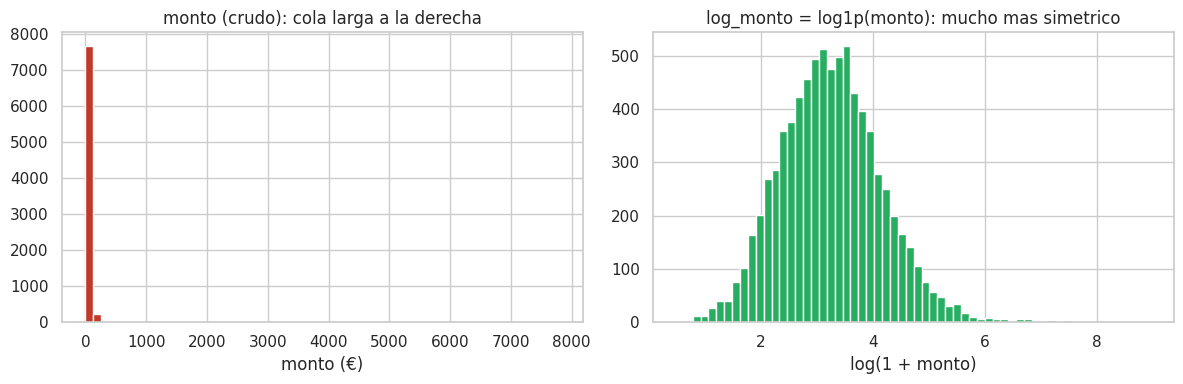

Asimetria despues de log: 0.5


In [ ]:
print("Asimetria (skew) del monto:", df["monto"].skew().round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["monto"], bins=60, color="#c0392b")
axes[0].set_title("monto (crudo): cola larga a la derecha")
axes[0].set_xlabel("monto (€)")

df["log_monto"] = np.log1p(df["monto"])
axes[1].hist(df["log_monto"], bins=60, color="#27ae60")
axes[1].set_title("log_monto = log1p(monto): mucho mas simetrico")
axes[1].set_xlabel("log(1 + monto)")
plt.tight_layout()
plt.show()

print("Asimetria despues de log:", df["log_monto"].skew().round(2))

In [ ]:
# Winsorizing: recortar el 1% mas extremo por cada lado
low, high = df["monto"].quantile([0.01, 0.99])
df["monto_winsor"] = df["monto"].clip(low, high)
print(f"Recorte aplicado: por debajo de {low:.2f}€ y por encima de {high:.2f}€")

# Yeo-Johnson: variante automatica del log (no requiere valores positivos)
yj = PowerTransformer(method="yeo-johnson")
df["monto_yeojohnson"] = yj.fit_transform(df[["monto"]])
print("Lambda estimada por Yeo-Johnson:", round(float(yj.lambdas_[0]), 3))

df[["monto", "log_monto", "monto_winsor", "monto_yeojohnson"]].describe().round(3)

Recorte aplicado: por debajo de 2.70€ y por encima de 285.19€
Lambda estimada por Yeo-Johnson: -0.142


,monto,log_monto,monto_winsor,monto_yeojohnson
count,"8,000.000","8,000.000","8,000.000","8,000.000"
mean,44.686,3.254,37.992,-0.000
std,146.291,0.922,44.314,1.000
min,0.640,0.495,2.700,-3.659
25%,12.760,2.622,12.760,-0.664
50%,24.095,3.223,24.095,0.031
75%,44.765,3.824,44.765,0.668
max,"7,789.290",8.961,285.189,4.369


### 7. Binning (discretizar)

A veces ayuda mas un **grupo** que el valor exacto: las franjas de edad (0-17, 18-30, 31-50…)
son un ejemplo. Dos formas:
- **No supervisado**: tramos iguales (`pd.cut`) o por frecuencia (`pd.qcut`). Rapido.
- **Supervisado**: tramos que miran el target. Potente, pero con mas riesgo de fuga.

In [16]:
# Binning por anchura fija sobre la edad (reglas de negocio)
df["franja_edad"] = pd.cut(
    df["edad"],
    bins=[0, 17, 30, 45, 60, 120],
    labels=["0-17", "18-30", "31-45", "46-60", "60+"],
)

# Binning por frecuencia (cuartiles) sobre el monto
df["monto_q"] = pd.qcut(df["monto"], q=4, labels=["bajo", "medio", "alto", "muy_alto"])

print("Tasa de fraude por franja de edad:")
print(df.groupby("franja_edad", observed=True)["es_fraude"].mean().round(4))
print()
print("Tasa de fraude por cuartil de monto:")
print(df.groupby("monto_q", observed=True)["es_fraude"].mean().round(4))

Tasa de fraude por franja de edad:
franja_edad
18-30   0.096
31-45   0.087
46-60   0.098
60+     0.097
Name: es_fraude, dtype: float64

Tasa de fraude por cuartil de monto:
monto_q
bajo       0.056
medio      0.092
alto       0.086
muy_alto   0.147
Name: es_fraude, dtype: float64


### 7. `monto_ratio`: una interaccion con el cliente

24 € puede ser mucho o poco… **depende de la persona**. Una forma de explicarselo al
modelo es comparar el gasto de hoy con el gasto medio del cliente:

`monto_ratio = monto / gasto_medio_del_cliente`

In [ ]:
gasto_medio = df.groupby("id_cliente")["monto"].transform("mean")
df["monto_ratio"] = df["monto"] / gasto_medio
df['gasto_medio_cliente'] = gasto_medio
df[["id_cliente", "monto", "gasto_medio_cliente", "monto_ratio"]].head(8)

,id_cliente,monto,gasto_medio_cliente,monto_ratio
0,49,41.060,37.815,1.086
1,151,4.870,26.178,0.186
2,272,17.230,158.763,0.109
3,96,11.560,13.062,0.885
4,64,15.320,46.892,0.327
5,511,5.570,30.032,0.185
6,224,10.030,34.575,0.290
7,350,6.930,25.973,0.267


### 8. Sacar señales del tiempo

Una fecha sola dice poco: `2024-05-15 16:30`. Pero podemos **partirla** en piezas utiles
para detectar fraude: año, mes, dia, hora, dia de la semana, si es de madrugada o fin de semana…

In [17]:
df["anio"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["dia"] = df["fecha"].dt.day
df["hora"] = df["fecha"].dt.hour
df["dia_semana"] = df["fecha"].dt.dayofweek          # 0=lunes ... 6=domingo
df["es_finde"] = (df["dia_semana"] >= 5).astype(int)
df["es_madrugada"] = (df["hora"] < 6).astype(int)

df[["fecha", "mes", "hora", "dia_semana", "es_finde", "es_madrugada"]].head()

,fecha,mes,hora,dia_semana,es_finde,es_madrugada
0,2024-08-10 05:50:00,8,5,5,1,1
1,2024-10-02 18:10:00,10,18,2,0,0
2,2024-10-20 09:06:00,10,9,6,1,0
3,2024-02-25 14:43:00,2,14,6,1,0
4,2024-07-21 07:06:00,7,7,6,1,0


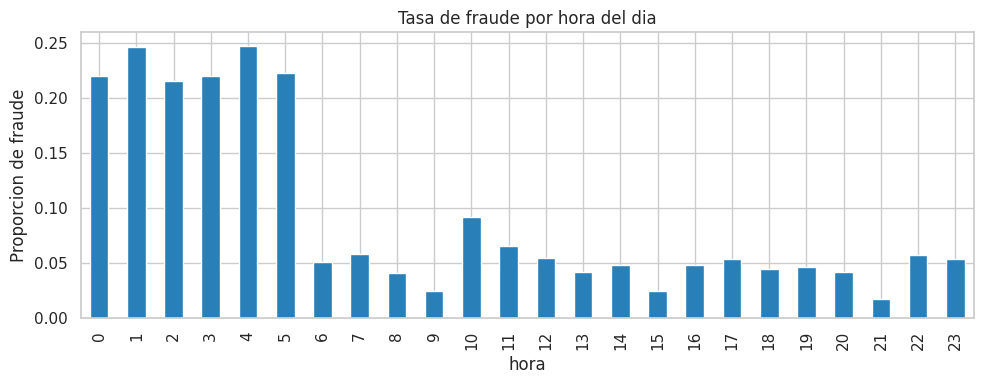

In [18]:
# ¿Tienen señal? Tasa de fraude segun la hora del dia
tasa_por_hora = df.groupby("hora")["es_fraude"].mean()
plt.figure(figsize=(10, 4))
tasa_por_hora.plot(kind="bar", color="#2980b9")
plt.title("Tasa de fraude por hora del dia")
plt.ylabel("Proporcion de fraude")
plt.xlabel("hora")
plt.tight_layout()
plt.show()

### El truco del reloj: encoding ciclico

La hora es **ciclica**: las 23:00 y las 00:00 estan juntas, pero como numeros (23 y 0)
quedan lejisimos. Lo arreglamos proyectando la hora en un circulo con seno y coseno.

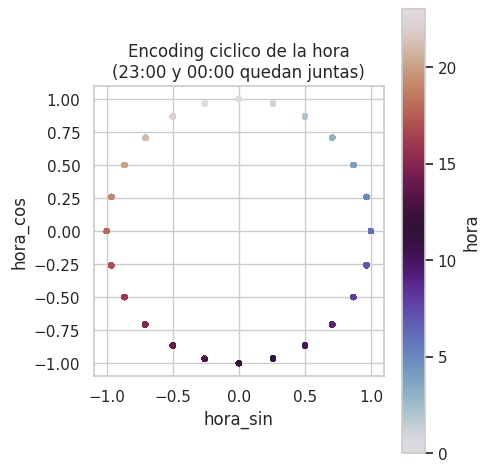

In [19]:
df["hora_sin"] = np.sin(2 * np.pi * df["hora"] / 24)
df["hora_cos"] = np.cos(2 * np.pi * df["hora"] / 24)

plt.figure(figsize=(5, 5))
sc = plt.scatter(df["hora_sin"], df["hora_cos"], c=df["hora"], cmap="twilight", s=10)
plt.colorbar(sc, label="hora")
plt.title("Encoding ciclico de la hora\n(23:00 y 00:00 quedan juntas)")
plt.xlabel("hora_sin")
plt.ylabel("hora_cos")
plt.gca().set_aspect("equal")
plt.tight_layout()
plt.show()

In [25]:
df[["hora", "hora_sin", "hora_cos", "es_fraude"]]

,hora,hora_sin,hora_cos,es_fraude
0,5,0.966,0.259,1
1,18,-1.000,-0.000,0
2,9,0.707,-0.707,0
3,14,-0.500,-0.866,0
4,7,0.966,-0.259,0
...,...,...,...,...
7995,12,0.000,-1.000,0
7996,18,-1.000,-0.000,0
7997,2,0.500,0.866,1
7998,10,0.500,-0.866,0


### 10. `df.describe()` DESPUES de la ingenieria de variables

In [26]:
nuevas = ["log_monto", "monto_winsor", "monto_yeojohnson", "monto_ratio",
          "mes", "hora", "dia_semana", "es_finde", "es_madrugada", "hora_sin", "hora_cos"]
df[nuevas].describe().round(3)

,log_monto,monto_winsor,monto_yeojohnson,monto_ratio,mes,hora,dia_semana,es_finde,es_madrugada,hora_sin,hora_cos
count,"8,000.000","8,000.000","8,000.000","8,000.000","8,000.000","8,000.000","8,000.000","8,000.000","8,000.000","8,000.000","8,000.000"
mean,3.254,37.992,-0.000,1.000,6.538,11.348,3.027,0.290,0.263,0.013,0.016
std,0.922,44.314,1.000,1.075,3.425,7.000,2.011,0.454,0.440,0.700,0.714
min,0.495,2.700,-3.659,0.008,1.000,0.000,0.000,0.000,0.000,-1.000,-1.000
25%,2.622,12.760,-0.664,0.406,4.000,5.000,1.000,0.000,0.000,-0.707,-0.707
50%,3.223,24.095,0.031,0.727,7.000,11.000,3.000,0.000,0.000,0.000,0.000
75%,3.824,44.765,0.668,1.236,10.000,17.000,5.000,1.000,1.000,0.707,0.707
max,8.961,285.189,4.369,16.326,12.000,23.000,6.000,1.000,1.000,1.000,1.000


In [27]:
print("Columnas iniciales:", describe_antes.shape[1])
print("Columnas tras la ingenieria de variables:", df.select_dtypes('number').shape[1])
print()
print("Hemos pasado de los datos crudos a un conjunto de features con mas senal.")
df.head()

Columnas iniciales: 6
Columnas tras la ingenieria de variables: 19

Hemos pasado de los datos crudos a un conjunto de features con mas senal.


,id_cliente,edad,monto,pais,tipo_tarjeta,comercio,canal,codigo_postal,fecha,es_fraude,...,monto_q,anio,mes,dia,hora,dia_semana,es_finde,es_madrugada,hora_sin,hora_cos
0,49,19.000,41.060,FR,debito,COM_0004,online,50017,2024-08-10 05:50:00,1,...,alto,2024,8,10,5,5,1,1,0.966,0.259
1,151,NaN,4.870,DE,credito,COM_0019,presencial,8006,2024-10-02 18:10:00,0,...,bajo,2024,10,2,18,2,0,0,-1.000,-0.000
2,272,29.000,17.230,ES,debito,COM_0151,online,41030,2024-10-20 09:06:00,0,...,medio,2024,10,20,9,6,1,0,0.707,-0.707
3,96,71.000,11.560,ES,debito,COM_0033,online,50015,2024-02-25 14:43:00,0,...,bajo,2024,2,25,14,6,1,0,-0.500,-0.866
4,64,73.000,15.320,ES,credito,COM_0024,online,41026,2024-07-21 07:06:00,0,...,medio,2024,7,21,7,6,1,0,0.966,-0.259


### Reflexion

1. ¿Por que `RobustScaler` se comporta mejor que `MinMaxScaler` cuando hay outliers en el `monto`?
2. Mirando la tasa de fraude por hora, ¿que feature temporal parece mas util?
3. ¿Que ventaja aporta `monto_ratio` frente al `monto` a secas?
4. ¿En que casos el `binning` puede ayudar y en cuales podriamos estar perdiendo informacion?
5. El `codigo_postal` es pseudo-numerico. ¿Como lo codificarias para un modelo? (lo veremos en E2)